# Global Fuel Price Trends (1970–2026)

- Long-term oil price analysis
- Crisis detection (oil shocks, 2008, COVID)
- Volatility & trend analysis
- Forecasting future prices

In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
plt.style.use("ggplot")

In [2]:
df = pd.read_csv(r"C:\Users\Lenovo\Downloads\fuel_prices_1970_2026.csv")  
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

df.head()

,Date,Crude_Oil_Price
0,1970-01-01,1.21
1,1970-02-01,1.21
2,1970-03-01,1.21
3,1970-04-01,1.21
4,1970-05-01,1.21


In [3]:
print(df.shape)
df.describe()

(675, 2)


,Date,Crude_Oil_Price
count,675,675.000000
mean,1998-01-30 14:47:28,39.804040
min,1970-01-01 00:00:00,1.210000
25%,1984-01-16 12:00:00,16.533333
50%,1998-02-01 00:00:00,29.113333
75%,2012-02-15 12:00:00,61.246667
max,2026-03-01 00:00:00,132.825184
std,NaN,30.611456


In [ ]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Crude_Oil_Price"])

plt.title("Global Oil Price Trend (1970–2026)")
plt.xlabel("Year")
plt.ylabel("Price ($)")

plt.show()

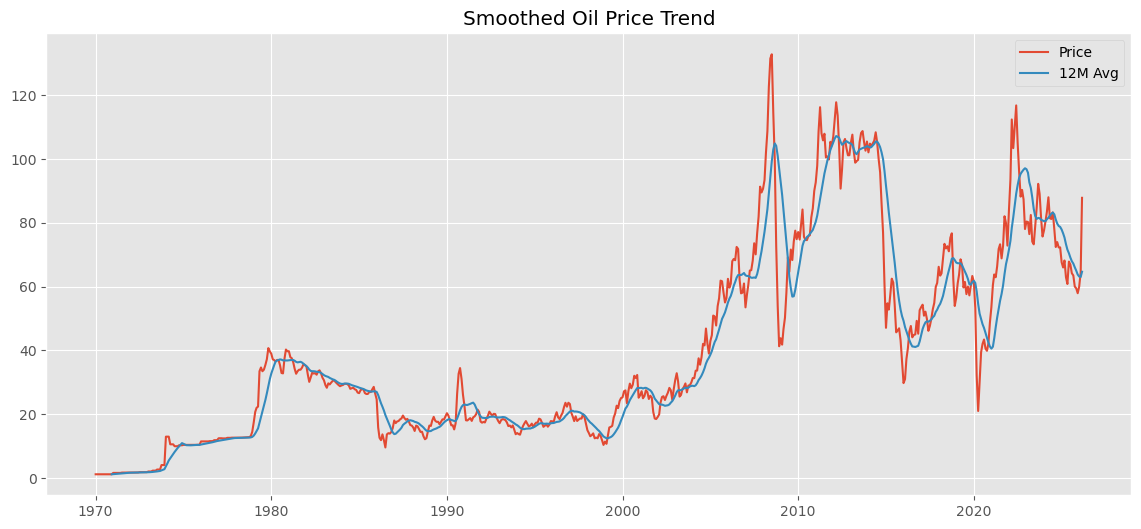

In [5]:
df["MA_12"] = df["Crude_Oil_Price"].rolling(12).mean()

plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Crude_Oil_Price"], label="Price")
plt.plot(df["Date"], df["MA_12"], label="12M Avg")

plt.legend()
plt.title("Smoothed Oil Price Trend")

plt.show()

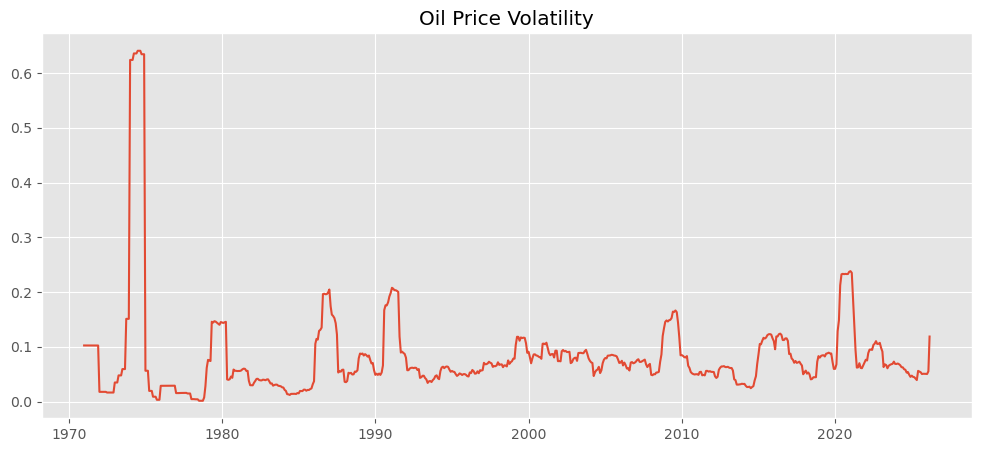

In [5]:
df["volatility"] = df["Crude_Oil_Price"].pct_change().rolling(12).std()

plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["volatility"])

plt.title("Oil Price Volatility")

plt.show()

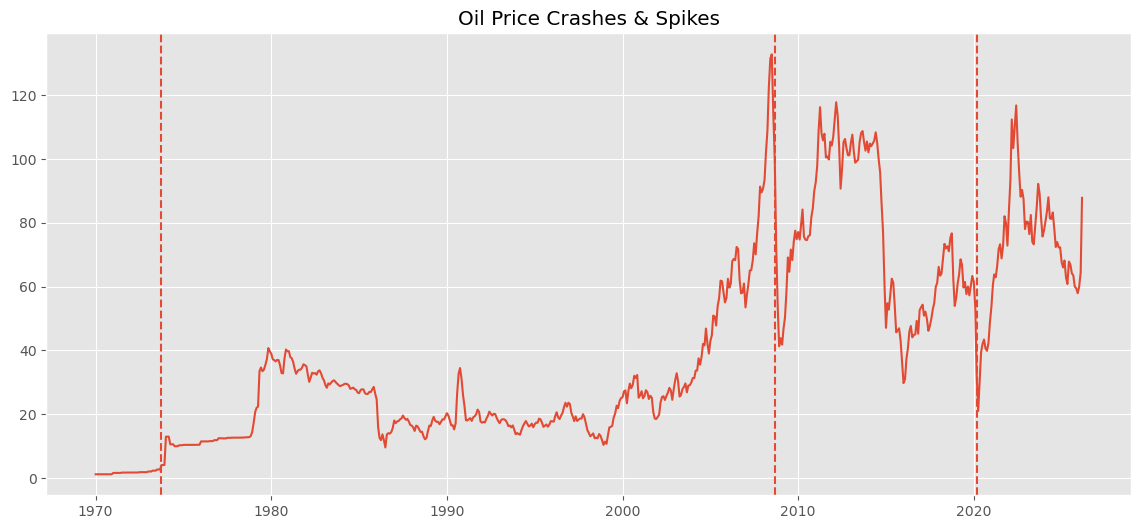

In [6]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Crude_Oil_Price"])

# major events
plt.axvline(pd.to_datetime("1973-10-01"), linestyle="--")
plt.axvline(pd.to_datetime("2008-09-01"), linestyle="--")
plt.axvline(pd.to_datetime("2020-03-01"), linestyle="--")

plt.title("Oil Price Crashes & Spikes")

plt.show()


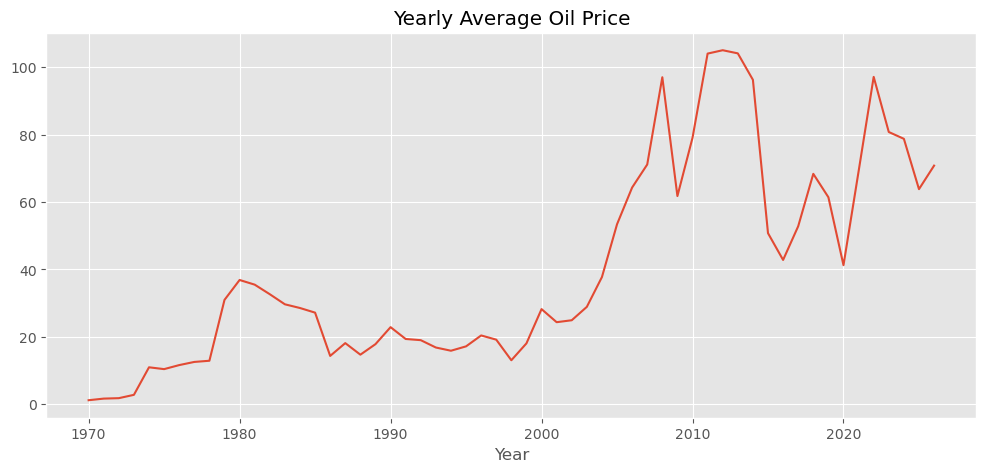

In [7]:
df["Year"] = df["Date"].dt.year

yearly = df.groupby("Year")["Crude_Oil_Price"].mean()

yearly.plot(figsize=(12,5))

plt.title("Yearly Average Oil Price")

plt.show()

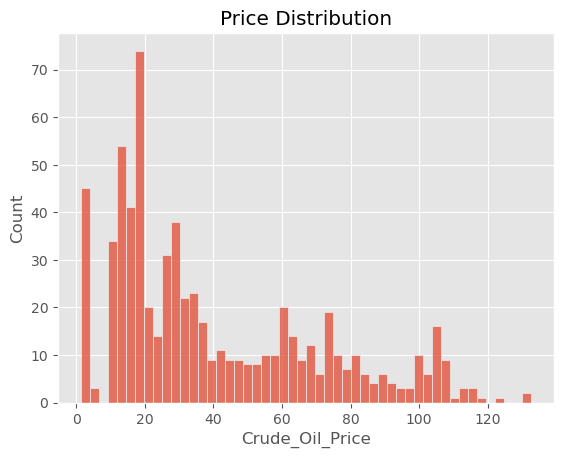

In [8]:
sns.histplot(df["Crude_Oil_Price"], bins=50)

plt.title("Price Distribution")

plt.show()

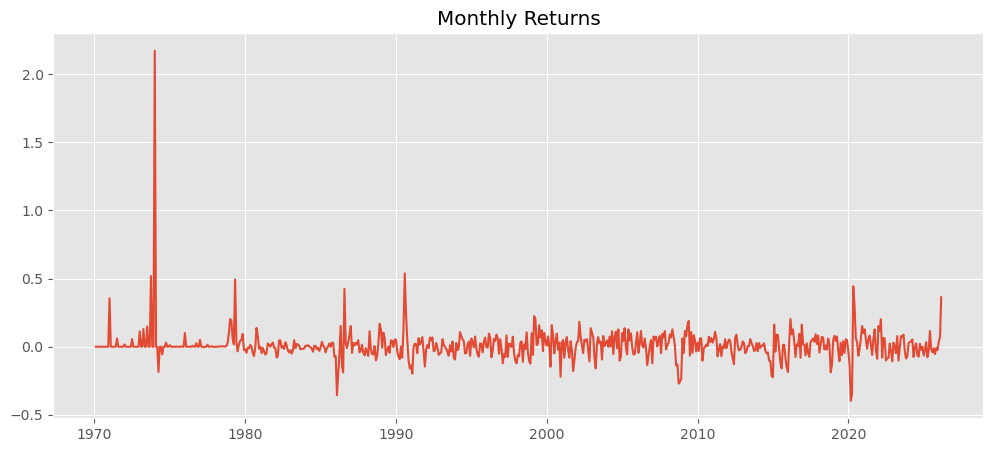

In [9]:
df["pct_change"] = df["Crude_Oil_Price"].pct_change()

plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["pct_change"])

plt.title("Monthly Returns")

plt.show()

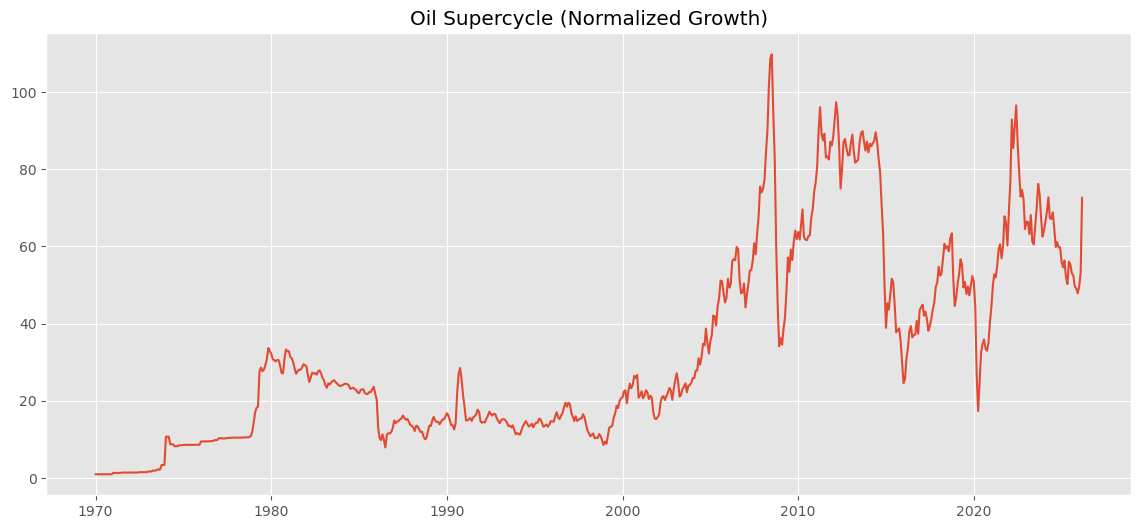

In [10]:
plt.figure(figsize=(14,6))

normalized = df["Crude_Oil_Price"] / df["Crude_Oil_Price"].iloc[0]

plt.plot(df["Date"], normalized)

plt.title("Oil Supercycle (Normalized Growth)")

plt.show()

In [11]:
df_model = df.copy()
df_model = df_model.sort_values("Date").reset_index(drop=True)

In [18]:
# Crewating new features
df_model["time"] = np.arange(len(df_model))
df_model["year"] = df_model["Date"].dt.year
df_model["month"] = df_model["Date"].dt.month
df_model["quarter"] = df_model["Date"].dt.quarter

In [19]:
# Creating lag Features
# Previous month
df_model["lag_1"] = df_model["Crude_Oil_Price"].shift(1)
# Previous 2 months
df_model["lag_2"] = df_model["Crude_Oil_Price"].shift(2)
# Previous 3 months
df_model["lag_3"] = df_model["Crude_Oil_Price"].shift(3)
# Previous 6 months
df_model["lag_6"] = df_model["Crude_Oil_Price"].shift(6)
# Previous 12 months
df_model["lag_12"] = df_model["Crude_Oil_Price"].shift(12)

In [20]:
df_model["rolling_mean_3"] = (df_model["Crude_Oil_Price"].shift(1).rolling(3).mean())
df_model["rolling_mean_6"] = (df_model["Crude_Oil_Price"].shift(1).rolling(6).mean())
df_model["rolling_mean_12"] = (df_model["Crude_Oil_Price"].shift(1).rolling(12).mean())

In [21]:
df_model = df_model.dropna().reset_index(drop=True)

In [25]:
features = ["time","year","month","quarter","lag_1","lag_2","lag_3","lag_6","lag_12","rolling_mean_3","rolling_mean_6","rolling_mean_12"]
X = df_model[features]
y = df_model["Crude_Oil_Price"]

In [26]:
split = int(len(df_model) * 0.80)
X_train = X.iloc[:split]
X_test = X.iloc[split:]
y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [30]:
model = RandomForestRegressor(n_estimators=300,max_depth=10,min_samples_split=5,random_state=42)
model.fit(X_train,y_train)

RandomForestRegressor(max_depth=10, min_samples_split=5, n_estimators=300,
                      random_state=42)

In [31]:
y_pred = model.predict(X_test)

In [33]:
r2 = r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
print("MODEL EVALUATION")
print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")

MODEL EVALUATION
R² Score : 0.8755
MAE      : 4.6042


In [40]:
test_results=pd.DataFrame({"Date": df_model["Date"].iloc[split:],"Actual": y_test.values,"Predicted": y_pred})

In [52]:
forecast_data=df_model.copy()

In [53]:
future_predictions = []

In [54]:
for i in range(24):
    next_time=len(forecast_data)
    next_date=(
        forecast_data["Date"].iloc[-1]
        + pd.offsets.MonthEnd(1)
    )
    lag_1 = forecast_data[
        "Crude_Oil_Price"
    ].iloc[-1]
    lag_2 = forecast_data[
        "Crude_Oil_Price"
    ].iloc[-2]
    lag_3 = forecast_data[
        "Crude_Oil_Price"
    ].iloc[-3]
    lag_6 = forecast_data[
        "Crude_Oil_Price"
    ].iloc[-6]
    lag_12 = forecast_data[
        "Crude_Oil_Price"
    ].iloc[-12]
    rolling_mean_3 = forecast_data[
        "Crude_Oil_Price"
    ].iloc[-3:].mean()
    rolling_mean_6 = forecast_data[
        "Crude_Oil_Price"
    ].iloc[-6:].mean()

    rolling_mean_12 = forecast_data[
        "Crude_Oil_Price"
    ].iloc[-12:].mean()
    future_row = pd.DataFrame({
        "time": [next_time],
        "year": [next_date.year],
        "month": [next_date.month],
        "quarter": [next_date.quarter],
        "lag_1": [lag_1],
        "lag_2": [lag_2],
        "lag_3": [lag_3],
        "lag_6": [lag_6],
        "lag_12": [lag_12],
        "rolling_mean_3": [rolling_mean_3],
        "rolling_mean_6": [rolling_mean_6],
        "rolling_mean_12": [rolling_mean_12]
    })
    next_prediction = model.predict(
        future_row[features]
    )[0]

    future_predictions.append(
        next_prediction
    )
    new_row = pd.DataFrame({
        "Date": [next_date],
        "Crude_Oil_Price": [next_prediction],
        "time": [next_time],
        "year": [next_date.year],
        "month": [next_date.month],
        "quarter": [next_date.quarter]
    })
    forecast_data = pd.concat(
        [forecast_data, new_row],
        ignore_index=True
    )
future_dates = pd.date_range(
    start=df_model["Date"].iloc[-1]
           + pd.offsets.MonthEnd(1),
    periods=24,
    freq="ME"
)
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecasted_Crude_Oil_Price":
        future_predictions
})

In [55]:
print("\n" + "=" * 50)
print("NEXT 24 MONTHS FORECAST")
print("=" * 50)
print(forecast_df.to_string(index=False))


NEXT 24 MONTHS FORECAST
      Date  Forecasted_Crude_Oil_Price
2026-03-31                   89.349453
2026-04-30                   93.214137
2026-05-31                   95.864048
2026-06-30                   97.211218
2026-07-31                  102.441641
2026-08-31                  106.474935
2026-09-30                  108.297907
2026-10-31                  108.318244
2026-11-30                  106.239303
2026-12-31                  104.990093
2027-01-31                  103.023314
2027-02-28                  101.264632
2027-03-31                  102.172166
2027-04-30                  103.810696
2027-05-31                  104.265443
2027-06-30                  104.882951
2027-07-31                  104.802020
2027-08-31                  104.603616
2027-09-30                  103.832366
2027-10-31                  102.663155
2027-11-30                  102.952113
2027-12-31                  103.438768
2028-01-31                  104.039423
2028-02-29                  104.028664


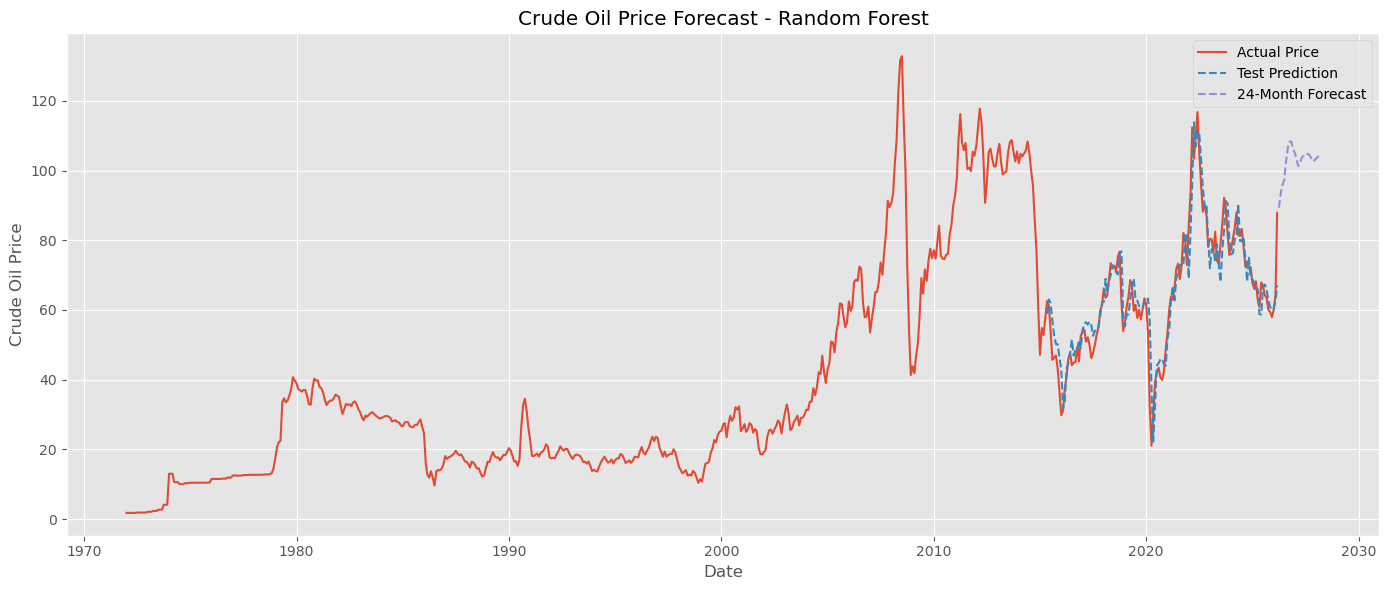

In [56]:
plt.figure(figsize=(14, 6))
plt.plot(df_model["Date"],df_model["Crude_Oil_Price"],label="Actual Price")
plt.plot(test_results["Date"],test_results["Predicted"],linestyle="--",label="Test Prediction")
plt.plot(forecast_df["Date"],forecast_df["Forecasted_Crude_Oil_Price"],linestyle="--",label="24-Month Forecast")
plt.xlabel("Date")
plt.ylabel("Crude Oil Price")
plt.title("Crude Oil Price Forecast - Random Forest")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

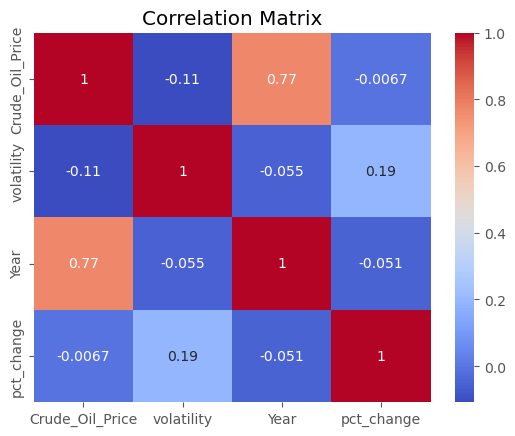

In [58]:
# Correlation Matrix
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()